In [2]:
from BWTEK import GlacierX
import matplotlib.pyplot as plt
import numpy as np

In [72]:
inst = GlacierX()
inst.readEEPROM()
print('EEPROM read into file')
inst.readConfig()
inttime = 5
print(inst.integrationTime(inttime))
print(f'integration time changed to {inttime}')
inst.getInterpolate()

Found 1 spectrometers , initialized 1
EEPROM read into file
5
integration time changed to 5


<function BWTEK.GlacierX.getInterpolate.<locals>.<lambda>(x)>

## Method 1

In [58]:
%%time
S = []
for i in range(1000):
    S.append(inst.readSpectrum())
S = np.array(S)
    

CPU times: total: 172 ms
Wall time: 9.79 s


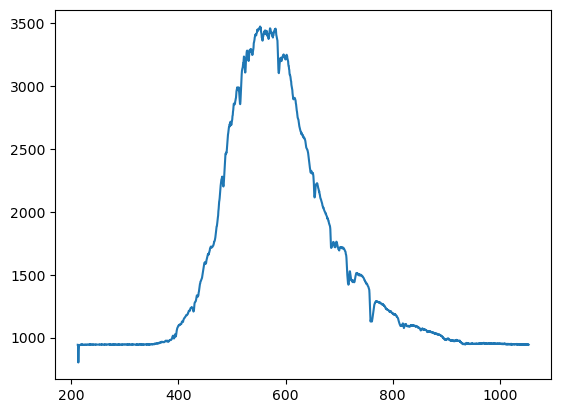

In [59]:
plt.plot(inst.wavelengths, np.mean(S, axis=0))
plt.show()

In [60]:
np.mean(S, axis=0)

array([943.601, 943.601, 802.889, ..., 944.611, 945.489, 944.305],
      dtype=float32)

## Method 2

In [61]:
%%time

spectrum = inst.readResult(1000, smooth_type=0)


CPU times: total: 93.8 ms
Wall time: 9.69 s


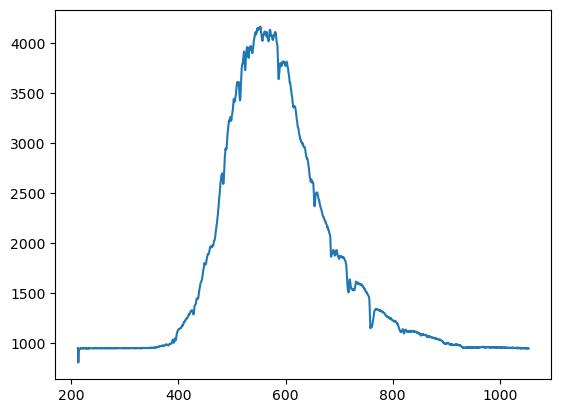

In [62]:
plt.plot(inst.wavelengths, spectrum)
plt.show()

In [63]:
spectrum

array([948., 948., 804., ..., 944., 944., 944.], dtype=float32)

## Method 3

In [64]:
%%time
S = np.zeros(inst.pixel_num, dtype='float32')
for i in range(1000):
    
    S += inst.readSpectrum()


CPU times: total: 156 ms
Wall time: 9.79 s


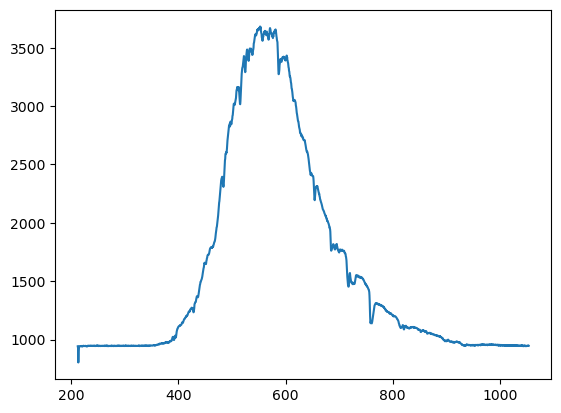

In [65]:
S = S / 1000
plt.plot(inst.wavelengths, S)
plt.show()

## Method 4

In [66]:
%%time
S = np.zeros((1000,inst.pixel_num), dtype='float32')
for i in range(1000): 
    S[i] = inst.readSpectrum()


CPU times: total: 234 ms
Wall time: 9.71 s


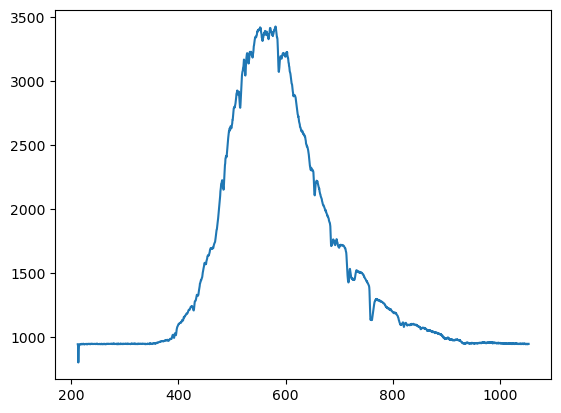

In [67]:
plt.plot(inst.wavelengths, np.mean(S, axis=0))
plt.show()

## Integration optimization

In [93]:
inttime = 100
print(inst.integrationTime(inttime))
print(f'integration time changed to {inttime}')
inst.getInterpolate()

100
integration time changed to 100


<function BWTEK.GlacierX.getInterpolate.<locals>.<lambda>(x)>

In [94]:
%%time
S = np.zeros((1000,inst.pixel_num), dtype='float32')
for i in range(1000): 
    S[i] = inst.readSpectrum()

CPU times: total: 297 ms
Wall time: 1min 44s


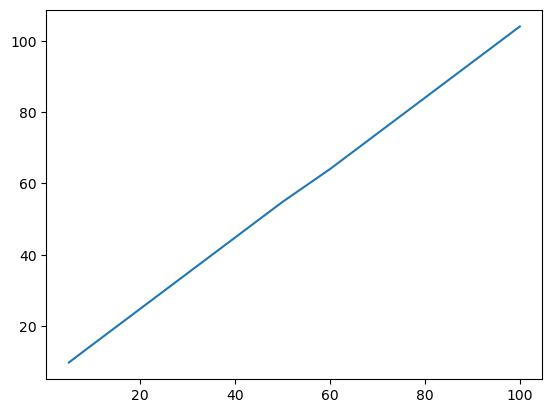

In [99]:
timings = {"acquired spectrums": 1000,
           "integration time (ms)": [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
           "Wall time (s)": [9.77, 14.8, 24.8, 34.8, 44.8, 54.8, 64, 74, 84, 94, 104] }

plt.plot(timings["integration time (ms)"], timings["Wall time (s)"])
plt.show()